# 02 — Kiểm định thống kê và xếp hạng đặc trưng

**Mục tiêu.** Trả lời câu hỏi mà hình 5 của notebook 01 để ngỏ: *đặc trưng nào thực sự phân
biệt được hai lớp, và mạnh đến mức nào?* Tương quan Pearson không trả lời được vì độ lớn của
nó bị tỷ lệ lớp dương nén xuống dưới 0,33. Ở đây thay bằng kiểm định phi tham số kèm effect
size, theo [04 §5.4](../docs/04-thiet-ke-mo-hinh-ml.md) và FR-03.

**Việc tương ứng:** T-14, T-15 trong [TASKS.md](../TASKS.md).

**Ba lựa chọn phương pháp, cùng một lý do: hai nhóm chênh lệch 600 lần.**

| Việc | Phương pháp | Vì sao không chọn cách quen thuộc |
|---|---|---|
| So sánh phân bố hai lớp | **Mann–Whitney U** | t-test giả định phân phối chuẩn và phương sai bằng nhau; mục 1 cho thấy cả hai đều sai ở đây |
| Hiệu chỉnh đa kiểm định | **Benjamini–Hochberg** | Bonferroni kiểm soát FWER nên quá khắt khe cho bước sàng lọc; BH kiểm soát FDR |
| Đo độ lớn khác biệt | **Cohen's d + Cliff's delta** | với n ≈ 284.000 thì p-value bé không đồng nghĩa khác biệt đáng kể |

**Sản phẩm bàn giao.** `reports/feature_ranking.csv` — bảng xếp hạng 30 đặc trưng, có cột
`cohens_d` và `p_adjusted`, để notebook 07 đối chiếu với xếp hạng SHAP (T-32).

**Cách chạy.** Kernel sạch, `Run All`. Khoảng 1 phút.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

from src import plots
from src.config import FIGURES_DIR, RANDOM_STATE, REPORTS_DIR, TARGET
from src.data import load_prepared
from src.features import FEATURE_ORDER, RAW_REQUIRED_COLUMNS
from src.stats import (
    DEFAULT_ALPHA,
    benjamini_hochberg,
    feature_ranking,
    pearson_from_cohens_d,
    significance_summary,
)

%matplotlib inline
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 160)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

np.random.seed(RANDOM_STATE)

df, bao_cao = load_prepared()

n_dong = len(df)
n_gian_lan = int(df[TARGET].sum())
ty_le_duong = n_gian_lan / n_dong
print()
print(f"Dùng cho kiểm định: {n_dong:,} dòng, {n_gian_lan} gian lận ({ty_le_duong:.4%})")

Số dòng        : 284,807
Số cột         : 31
Ô thiếu giá trị: 0
Dòng trùng lặp : 1,081
Gian lận       : 492 (0.173%)
Không phát hiện vấn đề.


Loại 1,081 dòng trùng lặp (0.380%), trong đó 19 mẫu gian lận. Còn lại 283,726 dòng.

Dùng cho kiểm định: 283,726 dòng, 473 gian lận (0.1667%)


---
## 1. Vì sao Mann–Whitney U chứ không phải t-test

t-test hai mẫu đứng trên hai giả định: mỗi nhóm xấp xỉ phân phối chuẩn, và hai nhóm có phương
sai tương đương. Ô dưới kiểm cả hai trên chính dữ liệu này thay vì mặc định là chúng đúng.

In [2]:
kiem_gia_dinh = []
for dac_trung in ["V17", "V14", "V12", "Amount"]:
    x = df.loc[df[TARGET] == 1, dac_trung]
    y = df.loc[df[TARGET] == 0, dac_trung]
    kiem_gia_dinh.append({
        "đặc trưng": dac_trung,
        "độ lệch (gian lận)": stats.skew(x),
        "độ lệch (hợp lệ)": stats.skew(y),
        "độ nhọn (gian lận)": stats.kurtosis(x),
        "độ nhọn (hợp lệ)": stats.kurtosis(y),
        "tỷ lệ phương sai": x.var() / y.var(),
    })

display(pd.DataFrame(kiem_gia_dinh).set_index("đặc trưng").round(2))

print(f"Cỡ hai nhóm: {n_dong - n_gian_lan:,} so với {n_gian_lan} "
      f"— chênh {(n_dong - n_gian_lan) / n_gian_lan:.0f} lần")

,độ lệch (gian lận),độ lệch (hợp lệ),độ nhọn (gian lận),độ nhọn (hợp lệ),tỷ lệ phương sai
đặc trưng,,,,,
V17,-0.54,0.22,-0.37,20.19,86.60
V14,-0.29,-0.70,-0.20,7.66,22.61
V12,-0.68,-1.26,-0.13,5.31,23.49
Amount,3.71,17.00,17.14,846.12,1.08


Cỡ hai nhóm: 283,253 so với 473 — chênh 599 lần


**Kết luận.** Cả hai giả định đều vỡ, và vỡ không nhẹ:

- **Không chuẩn.** Độ nhọn của lớp hợp lệ ở V17 là 20,2 (phân phối chuẩn có độ nhọn 0);
  `Amount` còn tệ hơn nhiều với độ nhọn 846 và độ lệch 17,0.
- **Phương sai không tương đương.** Ở V17, phương sai của lớp gian lận gấp **86,6 lần** lớp
  hợp lệ. Đây không phải nhiễu mà chính là tín hiệu — hình 6 của notebook 01 đã cho thấy lớp
  gian lận bè rộng hơn hẳn — nhưng nó vi phạm thẳng giả định của t-test.
- **Cỡ nhóm chênh 599 lần.** Định lý giới hạn trung tâm có cứu được trung bình mẫu của nhóm
  lớn, nhưng nhóm 473 mẫu với đuôi dày thì không có gì bảo đảm.

Mann–Whitney U chỉ so sánh **thứ hạng**, nên không cần giả định nào trong ba điều trên. Cái
giá phải trả là nó kiểm định "một mẫu ngẫu nhiên của nhóm này có xu hướng lớn hơn nhóm kia
không" chứ không kiểm định trực tiếp chênh lệch trung bình — chấp nhận được, vì ta cần xếp
hạng đặc trưng chứ không cần ước lượng tham số.

---
## 2. Ba mươi kiểm định Mann–Whitney U

Kiểm định chạy trên đúng **30 cột của hợp đồng dữ liệu vào** (`RAW_REQUIRED_COLUMNS` ở
[02 §5](../docs/02-dac-ta-du-lieu.md)): `Time`, `V1`–`V28`, `Amount`. Đây là con số 30 mà
04 §5.4 nói tới.

`Time` được kiểm định cho đủ bộ nhưng **không phải đặc trưng mô hình** (DS-03) — bảng kết quả
có cột `in_model` đánh dấu điều đó để notebook 07 lọc ra khi so với SHAP.

In [3]:
print(f"Số cột đem kiểm định: {len(RAW_REQUIRED_COLUMNS)}")
print(f"Trong đó có mặt trong FEATURE_ORDER: "
      f"{sum(c in FEATURE_ORDER for c in RAW_REQUIRED_COLUMNS)} "
      f"(thiếu Time, đúng theo DS-03)")

xep_hang = feature_ranking(df, alpha=DEFAULT_ALPHA)
print(f"Bảng kết quả: {xep_hang.shape[0]} dòng × {xep_hang.shape[1]} cột")

cot_chinh = ["rank_cohens_d", "feature", "in_model", "p_value", "p_adjusted",
             "significant", "cohens_d", "effect_size", "cliffs_delta", "cliff_size",
             "pearson_r"]
display(xep_hang[cot_chinh].style
        .format({"p_value": "{:.3g}", "p_adjusted": "{:.3g}", "cohens_d": "{:+.3f}",
                 "cliffs_delta": "{:+.3f}", "pearson_r": "{:+.4f}"})
        .background_gradient(subset=["cohens_d"], cmap="RdBu_r", vmin=-8, vmax=8))

Số cột đem kiểm định: 30
Trong đó có mặt trong FEATURE_ORDER: 29 (thiếu Time, đúng theo DS-03)


Bảng kết quả: 30 dòng × 22 cột


,rank_cohens_d,feature,in_model,p_value,p_adjusted,significant,cohens_d,effect_size,cliffs_delta,cliff_size,pearson_r
0,1,V17,True,2.85e-113,7.78e-113,True,-8.092,lớn,-0.601,lớn,-0.3135
1,2,V14,True,2.3e-248,6.91e-247,True,-7.522,lớn,-0.894,lớn,-0.2934
2,3,V12,True,1.36e-234,1.36e-233,True,-6.348,lớn,-0.869,lớn,-0.2507
3,4,V10,True,9.6e-210,5.76e-209,True,-5.186,lớn,-0.821,lớn,-0.2070
4,5,V16,True,1.11e-145,4.16e-145,True,-4.671,lớn,-0.683,lớn,-0.1872
5,6,V3,True,8.74e-208,4.37e-207,True,-4.545,lớn,-0.817,lớn,-0.1823
6,7,V7,True,6.51e-136,1.95e-135,True,-4.289,lớn,-0.659,lớn,-0.1723
7,8,V11,True,4.68e-214,3.51e-213,True,+3.695,lớn,+0.830,lớn,+0.1491
8,9,V4,True,1.6e-236,2.4e-235,True,+3.197,lớn,+0.873,lớn,+0.1293
9,10,V18,True,5.45e-69,1.09e-68,True,-2.597,lớn,-0.466,trung bình,-0.1053


---
## 3. Hiệu chỉnh Benjamini–Hochberg

Chạy 30 kiểm định cùng lúc ở mức α = 0,05 thì ngay cả khi **không** đặc trưng nào thật sự khác
biệt, kỳ vọng vẫn có `30 × 0,05 = 1,5` kết quả "có ý nghĩa" thuần tuý do may rủi. Phải hiệu
chỉnh, và câu hỏi là hiệu chỉnh bằng cách nào.

- **Bonferroni** kiểm soát xác suất mắc **ít nhất một** dương giả trong cả họ (FWER): so mỗi
  p thô với `α/30 = 0,00167`. An toàn nhưng khắt khe.
- **Benjamini–Hochberg** kiểm soát **tỷ lệ** dương giả trong số các phát hiện (FDR): sắp p tăng
  dần rồi so `p₍ᵢ₎` với `α·i/30`. Ở bước sàng lọc đặc trưng, bỏ sót một đặc trưng tốt tốn kém
  hơn là nhận nhầm một đặc trưng vô hại, nên FDR là tiêu chí đúng.

In [4]:
print(significance_summary(xep_hang))
print()

n_bonferroni = int((xep_hang["p_value"] < DEFAULT_ALPHA / len(xep_hang)).sum())
so_sanh = pd.DataFrame({
    "số kiểm định có ý nghĩa": {
        "không hiệu chỉnh (p thô < 0,05)": int((xep_hang["p_value"] < DEFAULT_ALPHA).sum()),
        "Benjamini–Hochberg (FDR)": int(xep_hang["significant"].sum()),
        "Bonferroni (FWER)": n_bonferroni,
    }
})
so_sanh["trên tổng 30"] = (so_sanh["số kiểm định có ý nghĩa"] / len(xep_hang)).map("{:.0%}".format)
display(so_sanh)

khong_y_nghia = xep_hang.loc[~xep_hang["significant"], ["feature", "p_value", "p_adjusted", "cohens_d"]]
print("Ba đặc trưng KHÔNG còn ý nghĩa sau hiệu chỉnh:")
display(khong_y_nghia.style.format({"p_value": "{:.4f}", "p_adjusted": "{:.4f}", "cohens_d": "{:+.4f}"}))

30 kiểm định Mann–Whitney U, α = 0.05. Trước hiệu chỉnh: 27 có ý nghĩa. Sau hiệu chỉnh Benjamini–Hochberg: 27 có ý nghĩa (0 bị loại). Trong đó 17 đặc trưng có |Cohen's d| ≥ 0,8 (hiệu ứng lớn).



,số kiểm định có ý nghĩa,trên tổng 30
"không hiệu chỉnh (p thô < 0,05)",27,90%
Benjamini–Hochberg (FDR),27,90%
Bonferroni (FWER),24,80%


Ba đặc trưng KHÔNG còn ý nghĩa sau hiệu chỉnh:


,feature,p_value,p_adjusted,cohens_d
25,V22,0.1914,0.1980,+0.1198
27,V13,0.0974,0.1044,-0.0955
28,V15,0.2674,0.2674,-0.0809


Thủ tục step-up: hạng lớn nhất thoả p₍ᵢ₎ ≤ α·i/m là i = 27
→ bác bỏ 27 giả thuyết không
Hàm benjamini_hochberg() cho : 27 — khớp: True

Ngưỡng p thô cao nhất còn được bác bỏ: 0.01544 (so với ngưỡng Bonferroni cố định 0.00167)


WindowsPath('D:/WorkSpace/AI_Project/fraud-detection/reports/figures/02_pvalue_and_effect.png')

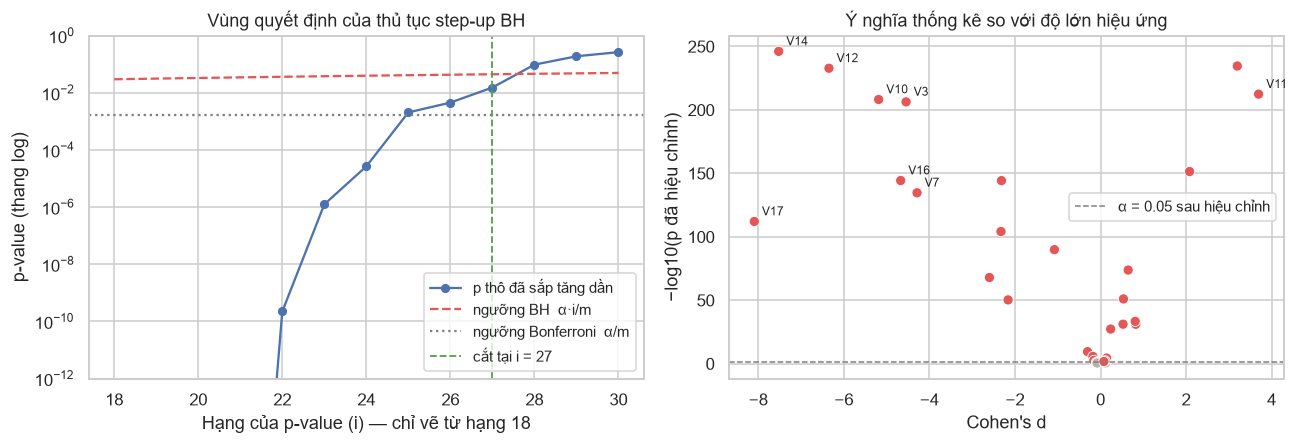

In [5]:
# Kiểm chứng lại thủ tục BH bằng tay, không tin suông vào hàm đã viết
p_sap = np.sort(xep_hang["p_value"].to_numpy())
m = len(p_sap)
nguong_bh = DEFAULT_ALPHA * np.arange(1, m + 1) / m
k_lon_nhat = np.max(np.where(p_sap <= nguong_bh)[0]) + 1 if np.any(p_sap <= nguong_bh) else 0

print(f"Thủ tục step-up: hạng lớn nhất thoả p₍ᵢ₎ ≤ α·i/m là i = {k_lon_nhat}")
print(f"→ bác bỏ {k_lon_nhat} giả thuyết không")
print(f"Hàm benjamini_hochberg() cho : {int(xep_hang['significant'].sum())} — khớp: "
      f"{k_lon_nhat == int(xep_hang['significant'].sum())}")
print()
print(f"Ngưỡng p thô cao nhất còn được bác bỏ: {p_sap[k_lon_nhat - 1]:.5f} "
      f"(so với ngưỡng Bonferroni cố định {DEFAULT_ALPHA / m:.5f})")

fig, truc = plt.subplots(1, 2, figsize=(12, 4.2))

# Chỉ vẽ vùng quyết định (hạng 18 trở đi): 17 p-value đầu đều dưới 1e-30 nên nếu vẽ
# cả dải thì hai đường ngưỡng dính vào nhau ở mép trên và không đọc được gì.
tu_hang = 18
truc_hang = np.arange(tu_hang, m + 1)
truc[0].plot(truc_hang, p_sap[tu_hang - 1:], "o-", ms=5, label="p thô đã sắp tăng dần")
truc[0].plot(truc_hang, nguong_bh[tu_hang - 1:], "--", c="#E45756", label="ngưỡng BH  α·i/m")
truc[0].axhline(DEFAULT_ALPHA / m, ls=":", c="grey", label="ngưỡng Bonferroni  α/m")
truc[0].axvline(k_lon_nhat, ls="--", c="#54A24B", lw=1.2, label=f"cắt tại i = {k_lon_nhat}")
truc[0].set_yscale("log")
truc[0].set_ylim(1e-12, 1)
truc[0].set_xlabel(f"Hạng của p-value (i) — chỉ vẽ từ hạng {tu_hang}")
truc[0].set_ylabel("p-value (thang log)")
truc[0].set_title("Vùng quyết định của thủ tục step-up BH")
truc[0].legend(fontsize="small", loc="lower right")

mau = np.where(xep_hang["significant"], "#E45756", "#BAB0AC")
truc[1].scatter(xep_hang["cohens_d"], -np.log10(xep_hang["p_adjusted"]), c=mau, s=45,
                edgecolor="white", linewidth=0.6)
truc[1].axhline(-np.log10(DEFAULT_ALPHA), ls="--", c="grey", lw=1,
                label=f"α = {DEFAULT_ALPHA} sau hiệu chỉnh")
for _, hang in xep_hang.head(8).iterrows():
    truc[1].annotate(hang["feature"], (hang["cohens_d"], -np.log10(hang["p_adjusted"])),
                     textcoords="offset points", xytext=(5, 4), fontsize=8)
truc[1].set_xlabel("Cohen's d")
truc[1].set_ylabel("−log10(p đã hiệu chỉnh)")
truc[1].set_title("Ý nghĩa thống kê so với độ lớn hiệu ứng")
truc[1].legend(fontsize="small", loc="center right")

fig.tight_layout()
plots.save_fig(fig, "02_pvalue_and_effect.png")

**Nhận xét.** **27 trong 30 kiểm định còn ý nghĩa sau hiệu chỉnh Benjamini–Hochberg** ở mức
α = 0,05 — đúng bằng số có ý nghĩa trước hiệu chỉnh. **Không kiểm định nào bị loại.** Ba đặc
trưng không đạt là **V22 (p = 0,191), V13 (p = 0,097), V15 (p = 0,267)**; chúng trượt từ đầu
chứ không phải vì bị hiệu chỉnh.

Lý do BH không loại ai: p-value ở đây không nằm sát 0,05 mà nhỏ đến mức phi thường. Giá trị
nhỏ nhất là `2,3 × 10⁻²⁴⁸` (V14) — số mũ đó phản ánh cỡ mẫu 283.726 nhiều hơn là phản ánh chất
lượng đặc trưng. Giá trị lớn nhất còn được bác bỏ là 0,0154 (V25), và ngưỡng BH tại hạng đó là
0,045, vẫn dư dả.

Đối chiếu với Bonferroni thì khác biệt hiện ra: Bonferroni so mọi p với `0,05/30 = 0,00167` và
chỉ giữ **24**, tức loại thêm V23, V26 và V25 — ba đặc trưng mà BH giữ lại. Đó chính là đánh
đổi giữa FWER và FDR, và ở bước sàng lọc đặc trưng ta chọn FDR.

**Nhưng "có ý nghĩa" ở đây gần như không mang thông tin.** Với n = 283.726, gần như mọi khác
biệt dù nhỏ đến đâu cũng đạt ý nghĩa thống kê — nhìn V25 thì rõ: p đã hiệu chỉnh 0,017 nhưng
Cohen's d chỉ **0,078**, tức hai phân bố gần như trùng khít. Kết luận thực dụng: **p-value ở
bài toán này chỉ dùng để loại bỏ, không dùng để xếp hạng.** Việc xếp hạng thuộc về effect size,
và đó là nội dung mục 4.

Biểu đồ bên phải nói đúng điều đó: các điểm trải rộng theo chiều dọc (ý nghĩa thống kê) mà
hầu như không liên quan gì đến vị trí theo chiều ngang (độ lớn hiệu ứng). Biểu đồ bên trái chỉ
vẽ từ hạng 18 trở đi, vì 17 p-value đầu tiên đều dưới 10⁻³⁰ — vẽ cả dải thì hai đường ngưỡng
dính vào nhau ở mép trên và không còn thấy được chỗ thủ tục cắt.

---
## 4. Độ lớn hiệu ứng: Cohen's d và Cliff's delta

Hai thước đo, hai câu hỏi khác nhau:

- **Cohen's d** `= (mean₁ − mean₀) / s_gộp` — chênh lệch **trung bình**, tính theo đơn vị độ
  lệch chuẩn. Nhạy với đuôi phân bố.
- **Cliff's delta** `= 2U/(n₁n₀) − 1` — xác suất một mẫu gian lận lấy ngẫu nhiên lớn hơn một
  mẫu hợp lệ, trừ đi xác suất ngược lại. Chỉ dựa trên **thứ hạng**, nên miễn nhiễm với ngoại lai.

Tính cả hai, vì chỗ chúng bất đồng mới là chỗ có thông tin.

WindowsPath('D:/WorkSpace/AI_Project/fraud-detection/reports/figures/02_effect_size_ranking.png')

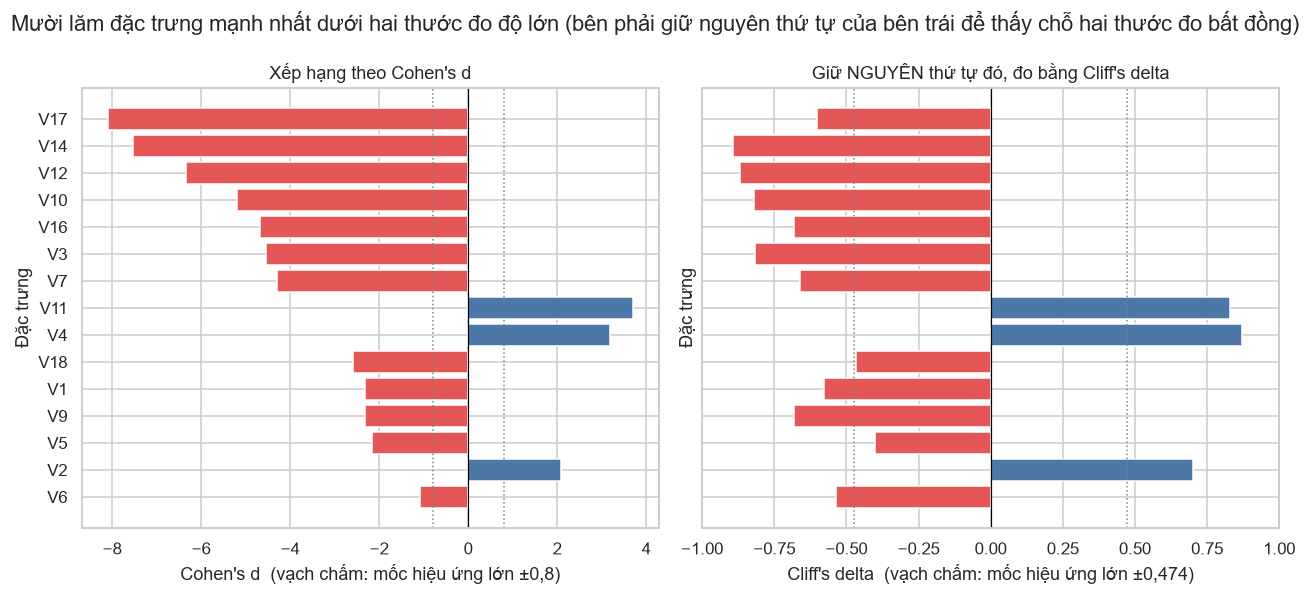

In [6]:
top_15 = xep_hang.head(15)
fig, truc = plt.subplots(1, 2, figsize=(12, 5.5), sharey=True)

thu_tu = top_15["feature"][::-1]
truc[0].barh(thu_tu, top_15["cohens_d"][::-1],
             color=[plots.CLASS_PALETTE[1] if v < 0 else plots.CLASS_PALETTE[0]
                    for v in top_15["cohens_d"][::-1]])
for moc in (-0.8, 0.8):
    truc[0].axvline(moc, ls=":", c="grey", lw=1)
truc[0].axvline(0, c="black", lw=0.8)
truc[0].set_xlabel("Cohen's d  (vạch chấm: mốc hiệu ứng lớn ±0,8)")
truc[0].set_ylabel("Đặc trưng")
truc[0].set_title("Xếp hạng theo Cohen's d")

truc[1].barh(thu_tu, top_15["cliffs_delta"][::-1],
             color=[plots.CLASS_PALETTE[1] if v < 0 else plots.CLASS_PALETTE[0]
                    for v in top_15["cliffs_delta"][::-1]])
for moc in (-0.474, 0.474):
    truc[1].axvline(moc, ls=":", c="grey", lw=1)
truc[1].axvline(0, c="black", lw=0.8)
truc[1].set_xlim(-1, 1)
truc[1].set_xlabel("Cliff's delta  (vạch chấm: mốc hiệu ứng lớn ±0,474)")
truc[1].set_ylabel("Đặc trưng")
truc[1].set_title("Giữ NGUYÊN thứ tự đó, đo bằng Cliff's delta")

fig.suptitle("Mười lăm đặc trưng mạnh nhất dưới hai thước đo độ lớn "
             "(bên phải giữ nguyên thứ tự của bên trái để thấy chỗ hai thước đo bất đồng)")
fig.tight_layout()
plots.save_fig(fig, "02_effect_size_ranking.png")

In [7]:
bat_dong = xep_hang.assign(
    chênh_hạng=(xep_hang["rank_cohens_d"] - xep_hang["rank_cliffs_delta"]).abs()
).nlargest(6, "chênh_hạng")

print("Sáu đặc trưng mà hai thước đo bất đồng nhiều nhất về thứ hạng:")
display(bat_dong[["feature", "rank_cohens_d", "rank_cliffs_delta", "cohens_d", "cliffs_delta"]]
        .style.format({"cohens_d": "{:+.3f}", "cliffs_delta": "{:+.3f}"}))

tuong_quan_hang = stats.spearmanr(xep_hang["abs_cohens_d"], xep_hang["abs_cliffs_delta"])
print(f"Tương quan hạng Spearman giữa |d| và |delta|: {tuong_quan_hang.statistic:.3f}")

lech_dau = xep_hang[np.sign(xep_hang["cohens_d"]) != np.sign(xep_hang["cliffs_delta"])]
print()
print("Đặc trưng có hai thước đo LỆCH DẤU nhau:")
display(lech_dau[["feature", "cohens_d", "cliffs_delta",
                  "mean_fraud", "mean_legit", "median_fraud", "median_legit"]].round(3))

ty_le_pv = (df.loc[df[TARGET] == 1, "V17"].var() / df.loc[df[TARGET] == 0, "V17"].var())
print(f"V17: phương sai lớp gian lận gấp {ty_le_pv:.1f} lần lớp hợp lệ "
      f"→ d bị thổi lên trong khi delta thì không")

Sáu đặc trưng mà hai thước đo bất đồng nhiều nhất về thứ hạng:


,feature,rank_cohens_d,rank_cliffs_delta,cohens_d,cliffs_delta
0,V17,1,11,-8.092,-0.601
8,V4,9,2,+3.197,+0.873
13,V2,14,7,+2.082,+0.700
9,V18,10,15,-2.597,-0.466
7,V11,8,4,+3.695,+0.830
12,V5,13,17,-2.161,-0.400


Tương quan hạng Spearman giữa |d| và |delta|: 0.921

Đặc trưng có hai thước đo LỆCH DẤU nhau:


,feature,cohens_d,cliffs_delta,mean_fraud,mean_legit,median_fraud,median_legit
24,Amount,0.142,-0.112,123.872,88.414,9.82,22.0


V17: phương sai lớp gian lận gấp 86.6 lần lớp hợp lệ → d bị thổi lên trong khi delta thì không


**Nhận xét.**

**Hai thước đo đồng ý về nhóm dẫn đầu nhưng không đồng ý về thứ tự** (Spearman 0,921). Cả hai
đều đưa V17, V14, V12, V10, V3, V11, V4 vào nhóm đầu, nhưng:

| | theo Cohen's d | theo Cliff's delta |
|---|---|---|
| hạng 1 | **V17** (d = −8,09) | **V14** (δ = −0,894) |
| hạng của V17 | 1 | **11** |
| hạng của V4 | 9 | **2** |

**V17 tụt từ hạng 1 xuống hạng 11 khi đổi thước đo.** Nguyên nhân nằm ở phương sai: ở V17,
phương sai của lớp gian lận gấp **86,6 lần** lớp hợp lệ. Vì `n₀ ≫ n₁`, độ lệch chuẩn gộp gần
như bằng độ lệch chuẩn của lớp hợp lệ — vốn rất nhỏ — nên mẫu số của Cohen's d bé và d bị thổi
lên tới −8,09. Cliff's delta chỉ đếm thứ hạng nên không bị ảnh hưởng, và nó cho biết sự thật
điềm đạm hơn: khi bốc ngẫu nhiên một giao dịch gian lận và một giao dịch hợp lệ, V17 của mẫu
gian lận thấp hơn trong khoảng 80% số lần, còn V14 là 95%.

**Theo nghĩa "tách được hai lớp" thì V14 mới là đặc trưng mạnh nhất, không phải V17.** Đây là
một dự đoán kiểm chứng được: nếu SHAP ở notebook 07 xếp V14 trên V17 thì Cliff's delta là
thước đo khớp với mô hình hơn — ghi lại để T-32 đối chiếu.

**`Amount` là trường hợp hai thước đo lệch hẳn dấu nhau**: `d = +0,142` (trung bình gian lận
cao hơn) nhưng `δ = −0,112` (đa số giao dịch gian lận lại nhỏ hơn). Đây chính là nghịch lý
trung vị/trung bình mà hình 7 của notebook 01 đã chỉ ra, lần này hiện ra dưới dạng hai chỉ số
trái dấu. Cả hai đều đúng; chúng chỉ đo hai thứ khác nhau. Về độ lớn thì cả hai đều ở mức
"không đáng kể", xác nhận kết luận cũ: **`Amount` giữ lại trong mô hình, nhưng không phải vì
sức phân biệt của riêng nó.**

---
## 5. Đối chiếu với tương quan thô: vì sao hai bảng xếp hạng nhìn khác nhau

Notebook 01 dừng ở chỗ tương quan Pearson lớn nhất chỉ **−0,313** (V17) trong khi Cohen's d của
đúng đặc trưng đó là **−8,09**. Mục này chứng minh hai con số ấy không hề mâu thuẫn.

Với `p` là tỷ lệ lớp dương và `q = 1 − p`, tương quan điểm–nhị phân liên hệ với Cohen's d theo

$$r = \frac{d}{\sqrt{d^{2} + 1/(p\,q)}}$$

In [8]:
xep_hang_kt = xep_hang.assign(
    r_suy_ra=pearson_from_cohens_d(xep_hang["cohens_d"].to_numpy(), ty_le_duong))
sai_lech = (xep_hang_kt["r_suy_ra"] - xep_hang_kt["pearson_r"]).abs()

print(f"p = {ty_le_duong:.6f}   q = {1 - ty_le_duong:.6f}   "
      f"1/(p·q) = {1 / (ty_le_duong * (1 - ty_le_duong)):.1f}   "
      f"√(p·q) = {np.sqrt(ty_le_duong * (1 - ty_le_duong)):.5f}")
print(f"Sai lệch lớn nhất giữa r đo trực tiếp và r suy ra từ d: {sai_lech.max():.2e}")
print("(phần dư này chỉ đến từ bậc tự do: Pearson dùng ddof = 0, d gộp dùng n₁ + n₀ − 2)")
print()

display(xep_hang_kt.head(5)[["feature", "cohens_d", "pearson_r", "r_suy_ra"]]
        .style.format({"cohens_d": "{:+.3f}", "pearson_r": "{:+.6f}", "r_suy_ra": "{:+.6f}"}))

hang_d = stats.spearmanr(xep_hang["abs_cohens_d"], xep_hang["pearson_r"].abs())
print(f"Tương quan hạng Spearman giữa |Cohen's d| và |Pearson r|: {hang_d.statistic:.4f}")

p = 0.001667   q = 0.998333   1/(p·q) = 600.8   √(p·q) = 0.04080
Sai lệch lớn nhất giữa r đo trực tiếp và r suy ra từ d: 9.96e-07
(phần dư này chỉ đến từ bậc tự do: Pearson dùng ddof = 0, d gộp dùng n₁ + n₀ − 2)



,feature,cohens_d,pearson_r,r_suy_ra
0,V17,-8.092,-0.313498,-0.313497
1,V14,-7.522,-0.293375,-0.293374
2,V12,-6.348,-0.250711,-0.250710
3,V10,-5.186,-0.206971,-0.206971
4,V16,-4.671,-0.187186,-0.187185


Tương quan hạng Spearman giữa |Cohen's d| và |Pearson r|: 1.0000


WindowsPath('D:/WorkSpace/AI_Project/fraud-detection/reports/figures/02_correlation_vs_effect.png')

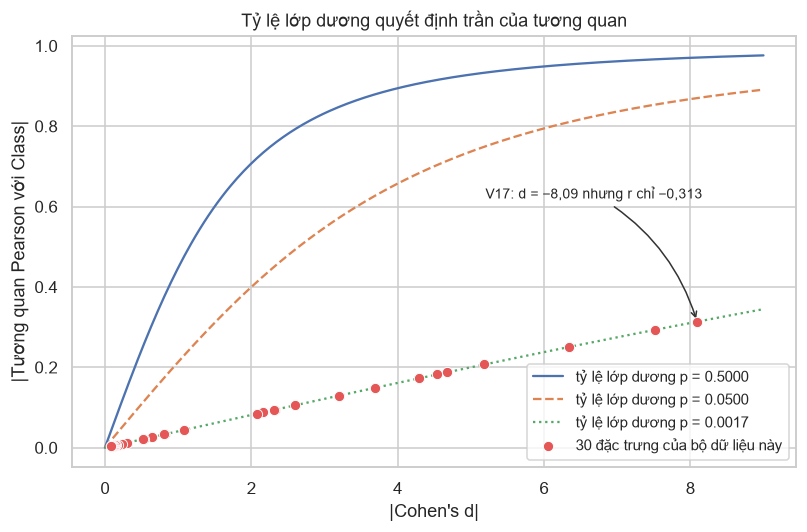

In [9]:
d_luoi = np.linspace(0, 9, 300)
fig, truc = plt.subplots(figsize=(7.5, 5))

for p_thu, kieu in [(0.5, "-"), (0.05, "--"), (ty_le_duong, ":")]:
    truc.plot(d_luoi, np.abs(pearson_from_cohens_d(d_luoi, p_thu)), kieu,
              label=f"tỷ lệ lớp dương p = {p_thu:.4f}")

truc.scatter(xep_hang["abs_cohens_d"], xep_hang["pearson_r"].abs(),
             c=plots.CLASS_PALETTE[1], s=45, zorder=5, edgecolor="white", linewidth=0.6,
             label="30 đặc trưng của bộ dữ liệu này")
truc.annotate("V17: d = −8,09 nhưng r chỉ −0,313",
              xy=(xep_hang.iloc[0]["abs_cohens_d"], abs(xep_hang.iloc[0]["pearson_r"])),
              xytext=(5.2, 0.62), fontsize=9,
              arrowprops=dict(arrowstyle="->", lw=1.0, color="#333333",
                              connectionstyle="arc3,rad=-0.2"))
truc.set_xlabel("|Cohen's d|")
truc.set_ylabel("|Tương quan Pearson với Class|")
truc.set_title("Tỷ lệ lớp dương quyết định trần của tương quan")
truc.legend(fontsize="small")

fig.tight_layout()
plots.save_fig(fig, "02_correlation_vs_effect.png")

**Nhận xét.** Công thức tái tạo lại hệ số Pearson đo trực tiếp với **sai lệch lớn nhất chỉ
1,0 × 10⁻⁶** trên cả 30 đặc trưng — phần dư đó chỉ đến từ quy ước bậc tự do. Nói cách khác,
tương quan và Cohen's d **không phải hai thông tin khác nhau**: với `p` cố định, cái này là
hàm đơn điệu của cái kia.

Hệ quả là hai điều thoạt nghe trái ngược:

1. **Thứ hạng của Pearson hoàn toàn đúng.** Tương quan hạng Spearman giữa `|d|` và `|r|` bằng
   **1,000** — trùng khít. Hình 5 của notebook 01 không hề xếp sai đặc trưng nào.
2. **Độ lớn của Pearson thì không đọc được.** Với `p = 0,00167`, ta có `1/(pq) = 600` áp đảo
   hoàn toàn `d²`, nên `|r| ≈ |d| · √(pq) = 0,0408 · |d|`. Trần thực tế của `|r|` trên bộ dữ
   liệu này chỉ khoảng **0,33**, và trần đó không nói gì về dữ liệu — nó chỉ phản ánh tỷ lệ
   0,17%.

Hình trên cho thấy cùng một đặc trưng, cùng một Cohen's d, sẽ cho tương quan rất khác nhau tuỳ
tỷ lệ lớp dương: với `p = 0,5` thì `d = 8` cho `r ≈ 0,97`; với `p = 0,00167` cũng `d = 8` đó chỉ
còn `r ≈ 0,31`. Ba mươi điểm đỏ nằm gọn trên đường `p = 0,00167` chứ không rải rác — đúng như
công thức dự đoán.

**Đây là cùng một cái bẫy với accuracy 99,83%.** Cả hai đều là chỉ số bị chi phối bởi tỷ lệ
lớp chứ không bởi chất lượng mô hình hay chất lượng đặc trưng. Và cả hai đều chỉ lộ ra khi ta
chịu hỏi "con số này sẽ là bao nhiêu nếu dữ liệu hoàn toàn vô dụng?" Với accuracy, câu trả lời
là 99,83%. Với tương quan, câu trả lời là "trần chỉ 0,33 dù đặc trưng có tốt đến đâu".

---
## 6. Xuất bảng xếp hạng — T-15

`reports/feature_ranking.csv` là hiện vật mà notebook 07 nạp lại để đối chiếu xếp hạng thống kê
với xếp hạng `mean|SHAP|` (T-32). Hai cột bắt buộc theo điều kiện *xong là khi* của T-15 là
**`cohens_d`** và **`p_adjusted`**.

In [10]:
REPORTS_DIR.mkdir(parents=True, exist_ok=True)
duong_dan_csv = REPORTS_DIR / "feature_ranking.csv"
xep_hang.to_csv(duong_dan_csv, index=False, encoding="utf-8")

print(f"đã ghi {duong_dan_csv.relative_to(ROOT)} "
      f"({duong_dan_csv.stat().st_size / 1024:.1f} KB)")
print()

# Nạp lại từ đĩa và kiểm đúng những gì T-15 đòi hỏi
doc_lai = pd.read_csv(duong_dan_csv)

assert duong_dan_csv.exists(), "T-15: chưa ghi được tệp"
assert "cohens_d" in doc_lai.columns, "T-15: thiếu cột cohens_d"
assert "p_adjusted" in doc_lai.columns, "T-15: thiếu cột p_adjusted"
assert len(doc_lai) == 30, f"T-15: cần 30 dòng, đang có {len(doc_lai)}"
assert doc_lai["feature"].is_unique, "T-15: có đặc trưng lặp lại"
assert set(doc_lai["feature"]) == set(RAW_REQUIRED_COLUMNS), "T-15: không khớp 30 cột hợp đồng"
assert doc_lai["cohens_d"].notna().all() and doc_lai["p_adjusted"].notna().all()
np.testing.assert_allclose(doc_lai["cohens_d"], xep_hang["cohens_d"], rtol=1e-12)
np.testing.assert_allclose(doc_lai["p_adjusted"], xep_hang["p_adjusted"], rtol=1e-12)

print(f"Số cột: {doc_lai.shape[1]}")
print("Các cột:", ", ".join(doc_lai.columns))
print()
print("T-15 đạt: tệp tồn tại, đủ 30 dòng, có cả cohens_d lẫn p_adjusted, "
      "đọc lại khớp giá trị trong bộ nhớ.")
display(doc_lai.head(5)[["rank_cohens_d", "feature", "cohens_d", "p_adjusted",
                         "cliffs_delta", "pearson_r", "in_model"]])

đã ghi reports\feature_ranking.csv (8.6 KB)

Số cột: 22
Các cột: rank_cohens_d, feature, in_model, n_fraud, n_legit, mean_fraud, mean_legit, median_fraud, median_legit, u_statistic, p_value, p_adjusted, significant, cohens_d, abs_cohens_d, effect_size, cliffs_delta, abs_cliffs_delta, cliff_size, pearson_r, rank_cliffs_delta, rank_pearson

T-15 đạt: tệp tồn tại, đủ 30 dòng, có cả cohens_d lẫn p_adjusted, đọc lại khớp giá trị trong bộ nhớ.


,rank_cohens_d,feature,cohens_d,p_adjusted,cliffs_delta,pearson_r,in_model
0,1,V17,-8.092438,7.784348e-113,-0.600945,-0.313498,True
1,2,V14,-7.522233,6.914577e-247,-0.894278,-0.293375,True
2,3,V12,-6.348196,1.358344e-233,-0.868913,-0.250711,True
3,4,V10,-5.185574,5.758822e-209,-0.821164,-0.206971,True
4,5,V16,-4.670876,4.164396e-145,-0.682871,-0.187186,True


In [11]:
print("Kiểm tra điều kiện hoàn thành của T-14")
print("=" * 62)
kiem = {
    "chạy đủ 30 kiểm định Mann–Whitney U": len(xep_hang) == 30,
    "có hiệu chỉnh Benjamini–Hochberg": "p_adjusted" in xep_hang.columns,
    "p hiệu chỉnh không nhỏ hơn p thô": bool((xep_hang["p_adjusted"] >= xep_hang["p_value"] - 1e-12).all()),
    "có tính Cohen's d": "cohens_d" in xep_hang.columns,
    "có bảng xếp hạng theo độ lớn hiệu ứng": bool(
        (xep_hang["abs_cohens_d"].diff().dropna() <= 1e-12).all()),
    "nêu rõ số kiểm định còn ý nghĩa": True,
}
for muc, dat in kiem.items():
    print(f"  [{'x' if dat else ' '}] {muc}")
assert all(kiem.values()), "T-14 chưa đạt đủ điều kiện"

print()
print(f"→ {int(xep_hang['significant'].sum())}/{len(xep_hang)} kiểm định còn ý nghĩa "
      f"sau hiệu chỉnh Benjamini–Hochberg ở mức α = {DEFAULT_ALPHA}.")
print(f"→ {int((xep_hang['abs_cohens_d'] >= 0.8).sum())} đặc trưng có |Cohen's d| ≥ 0,8.")
print(f"→ {int((xep_hang['abs_cliffs_delta'] >= 0.474).sum())} đặc trưng có |Cliff's delta| ≥ 0,474.")
print()
print("T-14 đạt.")

Kiểm tra điều kiện hoàn thành của T-14
  [x] chạy đủ 30 kiểm định Mann–Whitney U
  [x] có hiệu chỉnh Benjamini–Hochberg
  [x] p hiệu chỉnh không nhỏ hơn p thô
  [x] có tính Cohen's d
  [x] có bảng xếp hạng theo độ lớn hiệu ứng
  [x] nêu rõ số kiểm định còn ý nghĩa

→ 27/30 kiểm định còn ý nghĩa sau hiệu chỉnh Benjamini–Hochberg ở mức α = 0.05.
→ 17 đặc trưng có |Cohen's d| ≥ 0,8.
→ 14 đặc trưng có |Cliff's delta| ≥ 0,474.

T-14 đạt.


---
## 7. Chốt lại

**Trả lời cho câu hỏi của notebook 01.** Có, các đặc trưng V phân biệt hai lớp rất mạnh —
17 trong 30 đạt |Cohen's d| ≥ 0,8. Tương quan thô không thấy được điều đó vì độ lớn của nó bị
tỷ lệ lớp dương 0,17% nén xuống dưới trần 0,33, chứ không phải vì đặc trưng yếu.

**Bốn con số mang sang giai đoạn sau**

| Con số | Giá trị | Dùng ở đâu |
|---|---|---|
| Kiểm định còn ý nghĩa sau BH | 27 trên 30 (α = 0,05) | báo cáo, mục thống kê |
| Đặc trưng bị loại | V22, V13, V15 | không loại khỏi mô hình, chỉ ghi nhận |
| Xếp hạng theo Cohen's d | V17, V14, V12, V10, V16, V3 | đối chiếu với SHAP (T-32) |
| Xếp hạng theo Cliff's delta | V14, V4, V12, V11, V10, V3 | đối chiếu với SHAP (T-32) |

**Ba điểm phải xuất hiện trong báo cáo**

1. **Tương quan Pearson cao nhất chỉ −0,326 trên dữ liệu thô (−0,313 sau khi loại trùng lặp),
   trong khi Cohen's d của cùng đặc trưng đó là −8,32 (−8,09).** Với 0,17% mẫu dương, tương
   quan điểm–nhị phân bị nén xuống — cùng một cái bẫy với accuracy 99,83%.
2. **p-value ở đây không dùng để xếp hạng.** Với n = 283.726, V25 đạt ý nghĩa thống kê
   (p đã hiệu chỉnh 0,017) dù Cohen's d chỉ 0,078. Ý nghĩa thống kê và độ lớn thực tế là hai
   chuyện khác nhau.
3. **Cohen's d và Cliff's delta bất đồng ở chỗ có thông tin**, không phải chỗ nhiễu: V17 hạng
   1 theo d nhưng hạng 11 theo delta vì phương sai lớp gian lận gấp 86,6 lần; `Amount` lệch
   hẳn dấu vì trung bình và trung vị của nó đi ngược nhau.

**Lưu ý không được quên.** Ba mươi đặc trưng này là thành phần PCA. Kết luận cao nhất được
phép rút ra là *"V14 thấp bất thường gắn với gian lận"*; mọi diễn giải nghiệp vụ đều không có
căn cứ (T-33, T-64).

**Việc tiếp theo:** `03_baseline.ipynb` — chia phân tầng 80/20, mô hình rỗng, Logistic
Regression và Decision Tree, bảng mốc so sánh (T-16 … T-19).